# Analisis Statistika dan Probabilitas: Dataset Risiko Serangan Jantung
**Mata Kuliah:** Statistika dan Probabilitas (Semester 3)  
**Topik Utama:** Statistika Deskriptif, Teori Probabilitas, Distribusi Peluang, Teorema Limit Pusat, Estimasi Interval, Uji Hipotesis, Korelasi, dan Regresi Linier Sederhana  
**Dataset:** Data Pasien Risiko Serangan Jantung (`dataset/dataset_serangan_jantung.csv`)

---

## Deskripsi Singkat
Notebook ini disusun untuk mengimplementasikan materi perkuliahan **Statistika dan Probabilitas Semester 3** secara aplikatif pada dataset riil kesehatan. Setiap bab dilengkapi dengan formulasi matematis, implementasi kode Python, visualisasi grafis, serta interpretasi hasil secara komprehensif.

### Peta Materi Pembelajaran:
1. **Modul 1:** Eksplorasi & Pembersihan Awal Data
2. **Modul 2:** Statistika Deskriptif (Ukuran Pemusatan, Letak, Penyebaran, dan Bentuk Distribusi)
3. **Modul 3:** Teori Probabilitas, Peluang Bersyarat, dan Teorema Bayes
4. **Modul 4:** Distribusi Probabilitas Diskrit (Binomial, Poisson) & Kontinu (Normal/Gaussian)
5. **Modul 5:** Teori Penarikan Sampel, Teorema Limit Pusat (CLT), dan Estimasi Selang Kepercayaan (CI 95%)
6. **Modul 6:** Pengujian Hipotesis Statistik (Uji Beda Rata-rata Dua Sampel Independen & Uji Chi-Square Independensi)
7. **Modul 7:** Analisis Korelasi & Regresi Linier Sederhana
8. **Modul 8:** Rangkuman dan Kesimpulan Analisis


## Modul 1: Persiapan Lingkungan dan Pemuatan Dataset

Pada tahapan awal, kita mengimpor pustaka utama yang umum digunakan dalam komputasi statistika dan visualisasi data:
- `pandas` dan `numpy` untuk manipulasi data tabular dan komputasi numerik.
- `scipy.stats` untuk fungsi-fungsi distribusi probabilitas dan pengujian hipotesis.
- `matplotlib.pyplot` dan `seaborn` untuk penyajian visualisasi grafik statistik.
- `sklearn.linear_model` untuk pemodelan regresi.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Pengaturan tampilan grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Menentukan jalur dataset secara fleksibel
dataset_candidates = [
    'dataset/dataset_serangan_jantung.csv',
    '../dataset/dataset_serangan_jantung.csv',
    '/home/akbar/workspace/study/semester_3/statistic/tugas_uts/statistic_data/dataset/dataset_serangan_jantung.csv'
]

dataset_path = None
for path in dataset_candidates:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Berkas dataset_serangan_jantung.csv tidak ditemukan.")

print(f"Dataset berhasil dimuat dari: {dataset_path}")
df = pd.read_csv(dataset_path)

print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()


Dataset berhasil dimuat dari: ../dataset/dataset_serangan_jantung.csv
Jumlah baris: 79,583
Jumlah kolom: 16


,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack
0,PT00030699,F,31,25.9,0,112.0,1,0,0,0,0,0,0,90.969833,10,0
1,PT00018951,F,72,28.6,0,125.0,1,0,0,1,0,0,0,NaN,10,0
2,PT00027657,F,28,NaN,0,102.0,0,0,0,0,0,0,0,98.376954,10,0
3,PT00099298,F,63,NaN,0,NaN,0,0,0,0,0,0,0,NaN,10,0
4,PT00050564,F,35,NaN,0,111.0,1,0,0,0,0,0,0,NaN,10,0


### 1.1 Inspeksi Tipe Data dan Nilai Hilang (Missing Values)
Dalam statistika, data hilang perlu diidentifikasi karena dapat memengaruhi perhitungan parameter seperti rata-rata dan varians.


In [2]:
# Menampilkan ringkasan tipe data dan nilai hilang
missing_summary = pd.DataFrame({
    'Tipe Data': df.dtypes,
    'Jumlah Hilang': df.isnull().sum(),
    'Persentase Hilang (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Ringkasan Nilai Hilang Tiap Kolom:")
missing_summary[missing_summary['Jumlah Hilang'] > 0]


Ringkasan Nilai Hilang Tiap Kolom:


,Tipe Data,Jumlah Hilang,Persentase Hilang (%)
body_mass_index,float64,23832,29.95
systolic_blood_pressure,float64,7815,9.82
forced_expiratory_volume_1,float64,55253,69.43


---
## Modul 2: Statistika Deskriptif (Descriptive Statistics)

Statistika deskriptif bertujuan untuk merangkum dan mendeskripsikan karakteristik utama dari sekumpulan data tanpa menarik kesimpulan untuk populasi secara luas.

Terdapat empat kelompok ukuran utama:
1. **Ukuran Pemusatan (Central Tendency):**
   - **Mean (Rata-rata hitung):** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$
   - **Median (Nilai tengah):** Nilai pada posisi persentil ke-50 setelah data diurutkan.
   - **Modus (Mode):** Nilai dengan frekuensi kemunculan tertinggi.
2. **Ukuran Letak (Position):**
   - **Kuartil:** $Q_1$ (persentil ke-25), $Q_2$ (median / persentil ke-50), $Q_3$ (persentil ke-75).
   - **Interquartile Range (IQR):** $IQR = Q_3 - Q_1$. Digunakan untuk batas pencilan (Outlier):
     $$\text{Batas Bawah} = Q_1 - 1.5 \times IQR, \quad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$
3. **Ukuran Penyebaran (Dispersion):**
   - **Jangkauan (Range):** $x_{\max} - x_{\min}$
   - **Varians Sampel ($s^2$):** $s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$
   - **Standar Deviasi ($s$):** $s = \sqrt{s^2}$
   - **Koefisien Variasi ($CV$):** $CV = \left(\frac{s}{\bar{x}}\right) \times 100\%$ (mengukur variabilitas relatif).
4. **Ukuran Bentuk (Shape):**
   - **Skewness (Kemencengan):** Mengukur ketidaksimetrisan distribusi ($0$ simetris, $>0$ condong ke kanan/positif, $<0$ condong ke kiri/negatif).
   - **Kurtosis (Keruncingan):** Mengukur ketajaman puncak distribusi relatif terhadap distribusi normal ($0$ mesokurtik/normal, $>0$ leptokurtik, $<0$ platikurtik).


In [3]:
# Menghitung ukuran statistika deskriptif secara komprehensif untuk variabel numerik kontinu
numeric_cols = ['age', 'systolic_blood_pressure', 'body_mass_index']

desc_records = []
for col in numeric_cols:
    series = df[col].dropna()
    n = len(series)
    mean_val = series.mean()
    med_val = series.median()
    mode_val = series.mode().iloc[0]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    range_val = series.max() - series.min()
    var_sample = series.var(ddof=1)
    std_sample = series.std(ddof=1)
    cv = (std_sample / mean_val) * 100
    skew_val = stats.skew(series)
    kurt_val = stats.kurtosis(series)  # Fisher kurtosis (normal = 0)
    
    # Deteksi Outlier metode Tukey
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_cnt = ((series < lower_bound) | (series > upper_bound)).sum()
    
    desc_records.append({
        'Variabel': col,
        'N (Valid)': n,
        'Mean': round(mean_val, 2),
        'Median': round(med_val, 2),
        'Modus': round(mode_val, 2),
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Range': round(range_val, 2),
        'Varians (s^2)': round(var_sample, 2),
        'Standar Deviasi (s)': round(std_sample, 2),
        'CV (%)': round(cv, 2),
        'Skewness': round(skew_val, 3),
        'Kurtosis': round(kurt_val, 3),
        'Jumlah Outlier': outliers_cnt
    })

df_desc = pd.DataFrame(desc_records)
df_desc.T


,0,1,2
Variabel,age,systolic_blood_pressure,body_mass_index
N (Valid),79583,71768,55751
Mean,46.94,129.88,26.98
Median,47.0,129.0,27.1
Modus,22.0,127.0,27.9
Q1 (25%),32.0,118.0,24.1
Q3 (75%),61.0,141.0,30.0
IQR,29.0,23.0,5.9
Range,61.0,158.0,40.1
Varians (s^2),287.8,312.75,20.29


### 2.1 Visualisasi Distribusi: Histogram, KDE, dan Boxplot

Visualisasi data digunakan untuk mengonfirmasi bentuk kurva distribusi dan memeriksa keberadaan pencilan (outlier).


/tmp/ipykernel_5379/821831598.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='heart_attack', y='age', palette=['skyblue', 'salmon'], ax=axes[1, 0])
/tmp/ipykernel_5379/821831598.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(["0 = Tidak Serangan Jantung", "1 = Serangan Jantung"])
/tmp/ipykernel_5379/821831598.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='heart_attack', y='systolic_blood_pressure', palette=['skyblue', 'salmon'], ax=axes[1, 1])


/tmp/ipykernel_5379/821831598.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(["0 = Tidak Serangan Jantung", "1 = Serangan Jantung"])


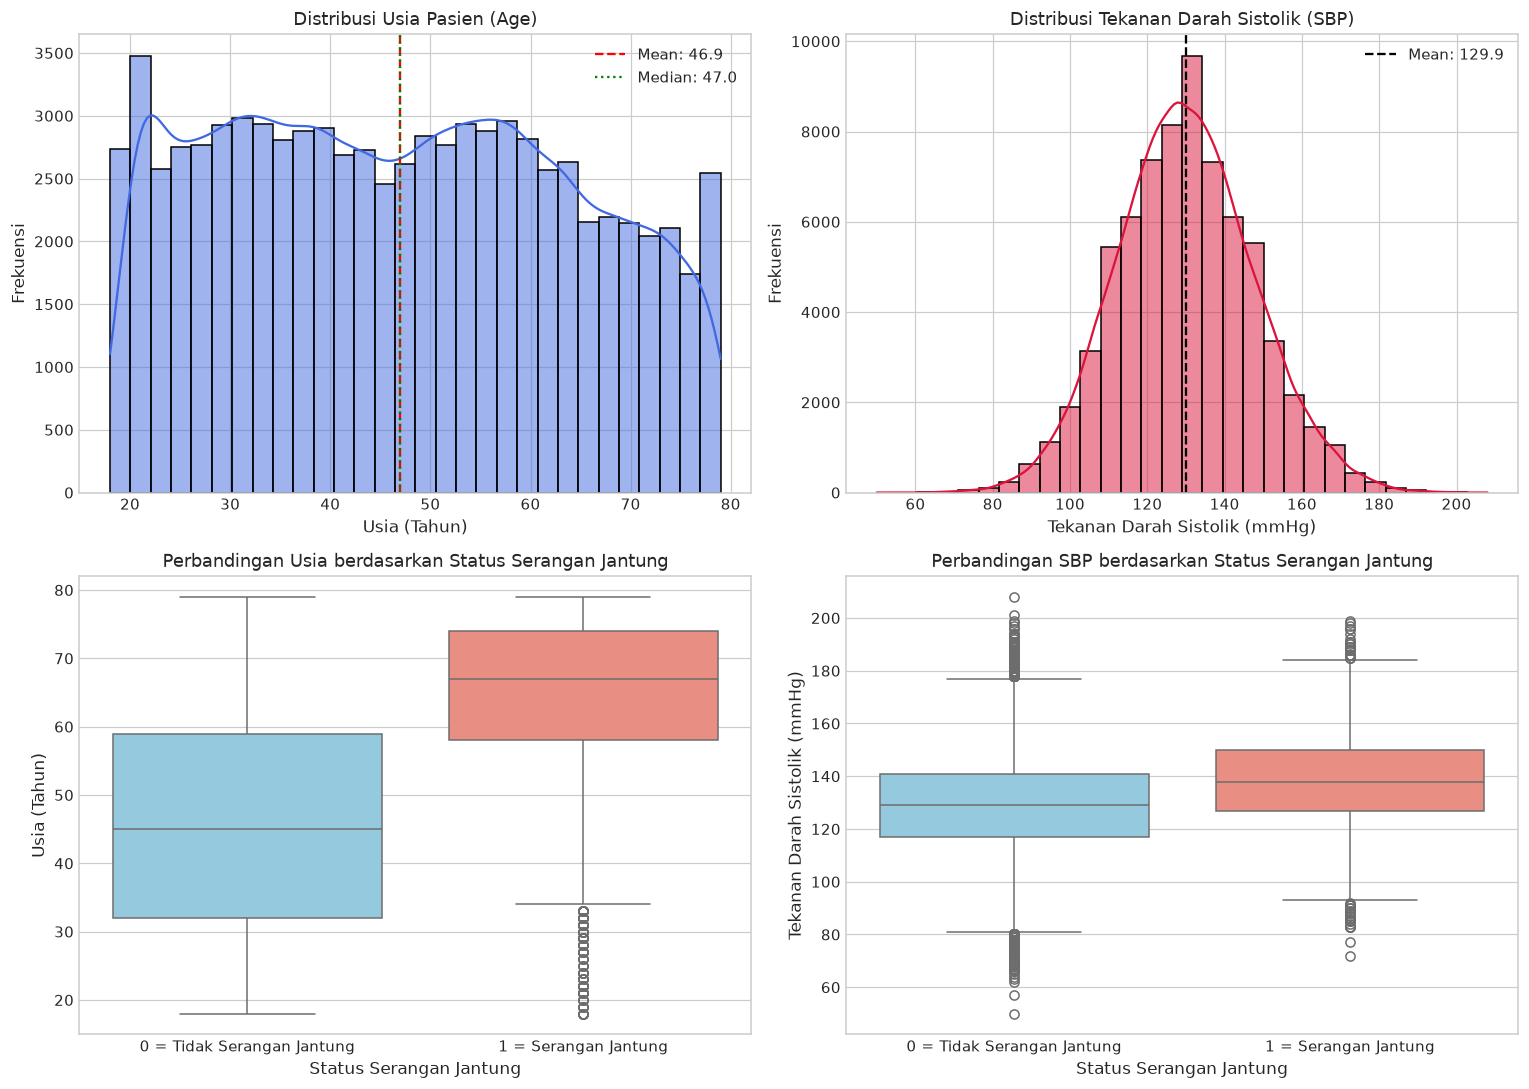

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram & KDE Usia
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='royalblue', bins=30)
axes[0, 0].set_title("Distribusi Usia Pasien (Age)")
axes[0, 0].set_xlabel("Usia (Tahun)")
axes[0, 0].set_ylabel("Frekuensi")
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
axes[0, 0].axvline(df['age'].median(), color='green', linestyle=':', label=f"Median: {df['age'].median():.1f}")
axes[0, 0].legend()

# 2. Histogram & KDE Tekanan Darah Sistolik
sbp_clean = df['systolic_blood_pressure'].dropna()
sns.histplot(sbp_clean, kde=True, ax=axes[0, 1], color='crimson', bins=30)
axes[0, 1].set_title("Distribusi Tekanan Darah Sistolik (SBP)")
axes[0, 1].set_xlabel("Tekanan Darah Sistolik (mmHg)")
axes[0, 1].set_ylabel("Frekuensi")
axes[0, 1].axvline(sbp_clean.mean(), color='black', linestyle='--', label=f"Mean: {sbp_clean.mean():.1f}")
axes[0, 1].legend()

# 3. Boxplot Usia berdasarkan Kejadian Serangan Jantung
sns.boxplot(data=df, x='heart_attack', y='age', palette=['skyblue', 'salmon'], ax=axes[1, 0])
axes[1, 0].set_title("Perbandingan Usia berdasarkan Status Serangan Jantung")
axes[1, 0].set_xticklabels(["0 = Tidak Serangan Jantung", "1 = Serangan Jantung"])
axes[1, 0].set_xlabel("Status Serangan Jantung")
axes[1, 0].set_ylabel("Usia (Tahun)")

# 4. Boxplot Tekanan Darah Sistolik berdasarkan Kejadian Serangan Jantung
sns.boxplot(data=df, x='heart_attack', y='systolic_blood_pressure', palette=['skyblue', 'salmon'], ax=axes[1, 1])
axes[1, 1].set_title("Perbandingan SBP berdasarkan Status Serangan Jantung")
axes[1, 1].set_xticklabels(["0 = Tidak Serangan Jantung", "1 = Serangan Jantung"])
axes[1, 1].set_xlabel("Status Serangan Jantung")
axes[1, 1].set_ylabel("Tekanan Darah Sistolik (mmHg)")

plt.tight_layout()
plt.show()


---
## Modul 3: Teori Probabilitas Dasar, Peluang Bersyarat, dan Teorema Bayes

Pada modul ini, kita menerapkan konsep probabilitas diskrit:
1. **Peluang Marginal / Prior:**
   $$P(A) = \frac{n(A)}{N}$$
2. **Peluang Bersyarat (Conditional Probability):**
   $$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$
   Menyatakan peluang kejadian $A$ terjadi jika diketahui kejadian $B$ telah terjadi.
3. **Uji Independensi Probabilistik:**
   Dua kejadian $A$ dan $B$ dikatakan saling bebas (independen) jika dan hanya jika:
   $$P(A \cap B) = P(A) \times P(B) \iff P(A \mid B) = P(A)$$
4. **Teorema Bayes:**
   $$P(B \mid A) = \frac{P(A \mid B) \cdot P(B)}{P(A)}$$
   Digunakan untuk memperbarui keyakinan probabilitas (*posterior probability*) setelah diperoleh informasi baru.


In [5]:
# Menghitung Peluang Marginal
N_total = len(df)
p_ha = (df['heart_attack'] == 1).mean()
p_no_ha = 1 - p_ha

p_smoker = (df['smoker'] == 1).mean()
p_diabetes = (df['diabetes'] == 1).mean()
p_fam_hist = (df['family_history_of_cardiovascular_disease'] == 1).mean()

print("--- 1. Peluang Marginal (Prior Probability) ---")
print(f"P(Heart Attack = 1)          : {p_ha:.4f} ({p_ha*100:.2f}%)")
print(f"P(Smoker = 1)                : {p_smoker:.4f} ({p_smoker*100:.2f}%)")
print(f"P(Diabetes = 1)              : {p_diabetes:.4f} ({p_diabetes*100:.2f}%)")
print(f"P(Family History CVD = 1)    : {p_fam_hist:.4f} ({p_fam_hist*100:.2f}%)")

# Peluang Bersyarat: P(Heart Attack | Faktor Risiko)
print("\n--- 2. Peluang Bersyarat P(Serangan Jantung | Kondisi) ---")
# Diabetes
p_ha_given_diab = df[df['diabetes'] == 1]['heart_attack'].mean()
p_ha_given_no_diab = df[df['diabetes'] == 0]['heart_attack'].mean()
rr_diab = p_ha_given_diab / p_ha_given_no_diab
print(f"P(Heart Attack | Diabetes = 1)     : {p_ha_given_diab:.4f} ({p_ha_given_diab*100:.2f}%)")
print(f"P(Heart Attack | Diabetes = 0)     : {p_ha_given_no_diab:.4f} ({p_ha_given_no_diab*100:.2f}%)")
print(f"Relative Risk (Diabetes)           : {rr_diab:.2f}x lipat")

# Riwayat Keluarga
p_ha_given_fam = df[df['family_history_of_cardiovascular_disease'] == 1]['heart_attack'].mean()
p_ha_given_no_fam = df[df['family_history_of_cardiovascular_disease'] == 0]['heart_attack'].mean()
print(f"\nP(Heart Attack | Riwayat Kel. = 1): {p_ha_given_fam:.4f} ({p_ha_given_fam*100:.2f}%)")
print(f"P(Heart Attack | Riwayat Kel. = 0): {p_ha_given_no_fam:.4f} ({p_ha_given_no_fam*100:.2f}%)")

# Uji Independensi Probabilistik antara Smoker dan Serangan Jantung
p_joint_smoker_ha = ((df['smoker'] == 1) & (df['heart_attack'] == 1)).mean()
p_independent_prod = p_smoker * p_ha

print("\n--- 3. Pemeriksaan Independensi Probabilistik (Smoker vs Heart Attack) ---")
print(f"P(Smoker ∩ Heart Attack) aktual : {p_joint_smoker_ha:.5f}")
print(f"P(Smoker) * P(Heart Attack)     : {p_independent_prod:.5f}")
print(f"Selisih |P(A ∩ B) - P(A)P(B)|    : {abs(p_joint_smoker_ha - p_independent_prod):.5f}")

# Teorema Bayes: Menghitung Posterior P(Diabetes | Heart Attack)
# P(Diabetes | HA) = [P(HA | Diabetes) * P(Diabetes)] / P(HA)
p_posterior_diab = (p_ha_given_diab * p_diabetes) / p_ha
p_posterior_diab_empiris = df[df['heart_attack'] == 1]['diabetes'].mean()

print("\n--- 4. Teorema Bayes ---")
print(f"P(Diabetes | Heart Attack = 1) via Teorema Bayes : {p_posterior_diab:.4f}")
print(f"P(Diabetes | Heart Attack = 1) hitungan langsung: {p_posterior_diab_empiris:.4f}")
print("Hasil Teorema Bayes identik dengan proporsi empiris pada data.")


--- 1. Peluang Marginal (Prior Probability) ---
P(Heart Attack = 1)          : 0.0664 (6.64%)
P(Smoker = 1)                : 0.0853 (8.53%)
P(Diabetes = 1)              : 0.0950 (9.50%)
P(Family History CVD = 1)    : 0.1664 (16.64%)

--- 2. Peluang Bersyarat P(Serangan Jantung | Kondisi) ---
P(Heart Attack | Diabetes = 1)     : 0.1673 (16.73%)
P(Heart Attack | Diabetes = 0)     : 0.0559 (5.59%)
Relative Risk (Diabetes)           : 3.00x lipat

P(Heart Attack | Riwayat Kel. = 1): 0.0764 (7.64%)
P(Heart Attack | Riwayat Kel. = 0): 0.0645 (6.45%)

--- 3. Pemeriksaan Independensi Probabilistik (Smoker vs Heart Attack) ---
P(Smoker ∩ Heart Attack) aktual : 0.00552
P(Smoker) * P(Heart Attack)     : 0.00567
Selisih |P(A ∩ B) - P(A)P(B)|    : 0.00015

--- 4. Teorema Bayes ---
P(Diabetes | Heart Attack = 1) via Teorema Bayes : 0.2392
P(Diabetes | Heart Attack = 1) hitungan langsung: 0.2392
Hasil Teorema Bayes identik dengan proporsi empiris pada data.


---
## Modul 4: Distribusi Probabilitas Teoretis (Diskrit & Kontinu)

### 4.1 Distribusi Probabilitas Diskrit: Distribusi Binomial & Poisson
1. **Distribusi Binomial:**  
   Bila sebuah klinik mengambil sampel acak sebanyak $n$ pasien secara independen, dan probabilitas pasien mengalami serangan jantung adalah $p$, maka variabel acak $X$ (jumlah pasien yang mengalami serangan jantung) berdistribusi Binomial:
   $$X \sim \text{Binomial}(n, p)$$
   $$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$
   Nilai Harapan: $E(X) = n p$, Varians: $\operatorname{Var}(X) = n p (1-p)$.

2. **Distribusi Poisson:**  
   Cocok untuk kejadian yang jarang terjadi (*rare events*) dalam interval tertentu dengan rata-rata kedatangan $\lambda$:
   $$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$


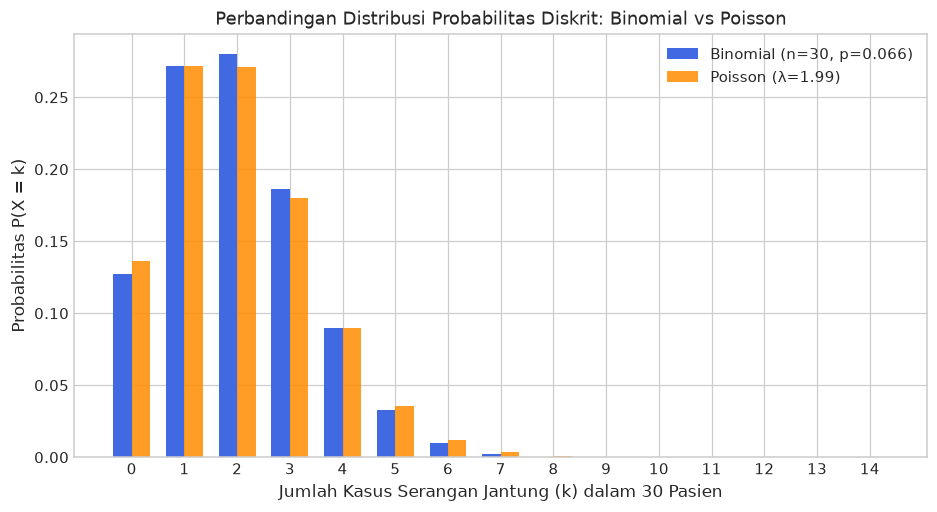

Probabilitas klinik menemukan LEBIH DARI 3 kasus dalam 30 pasien:
P(X > 3) = 1 - P(X <= 3) = 0.1353 (13.53%)


In [6]:
n_sampel = 30
p_event = p_ha
k_values = np.arange(0, 15)

# Menghitung PMF Binomial dan Poisson (lambda = n * p)
pmf_binomial = stats.binom.pmf(k_values, n_sampel, p_event)
lambda_poisson = n_sampel * p_event
pmf_poisson = stats.poisson.pmf(k_values, lambda_poisson)

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
ax.bar(k_values - bar_width/2, pmf_binomial, width=bar_width, label=f'Binomial (n={n_sampel}, p={p_event:.3f})', color='royalblue')
ax.bar(k_values + bar_width/2, pmf_poisson, width=bar_width, label=f'Poisson (λ={lambda_poisson:.2f})', color='darkorange', alpha=0.85)

ax.set_title("Perbandingan Distribusi Probabilitas Diskrit: Binomial vs Poisson")
ax.set_xlabel("Jumlah Kasus Serangan Jantung (k) dalam 30 Pasien")
ax.set_ylabel("Probabilitas P(X = k)")
ax.set_xticks(k_values)
ax.legend()
plt.show()

# Contoh perhitungan probabilitas:
p_lebih_dari_3 = 1 - stats.binom.cdf(3, n_sampel, p_event)
print(f"Probabilitas klinik menemukan LEBIH DARI 3 kasus dalam 30 pasien:")
print(f"P(X > 3) = 1 - P(X <= 3) = {p_lebih_dari_3:.4f} ({p_lebih_dari_3*100:.2f}%)")


### 4.2 Distribusi Probabilitas Kontinu: Distribusi Normal (Gaussian) & Standarisasi Z-Score

Variabel numerik kontinu seperti Tekanan Darah Sistolik ($X$) dapat dimodelkan dengan Distribusi Normal $X \sim \mathcal{N}(\mu, \sigma^2)$:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Untuk menghitung probabilitas kejadian kontinu, kita lakukan transformasi nilai ke variabel acak normal standar $Z \sim \mathcal{N}(0, 1)$:
$$Z = \frac{X - \mu}{\sigma}$$


Parameter Model Normal SBP: mu = 129.88 mmHg, sigma = 17.68 mmHg
Z-score untuk SBP = 140 mmHg   : 0.572
P(SBP >= 140) Teoretis (Normal): 0.2837 (28.37%)
P(SBP >= 140) Aktual (Empiris) : 0.2858 (28.58%)
Deviasi Model vs Realitas      : 0.21%


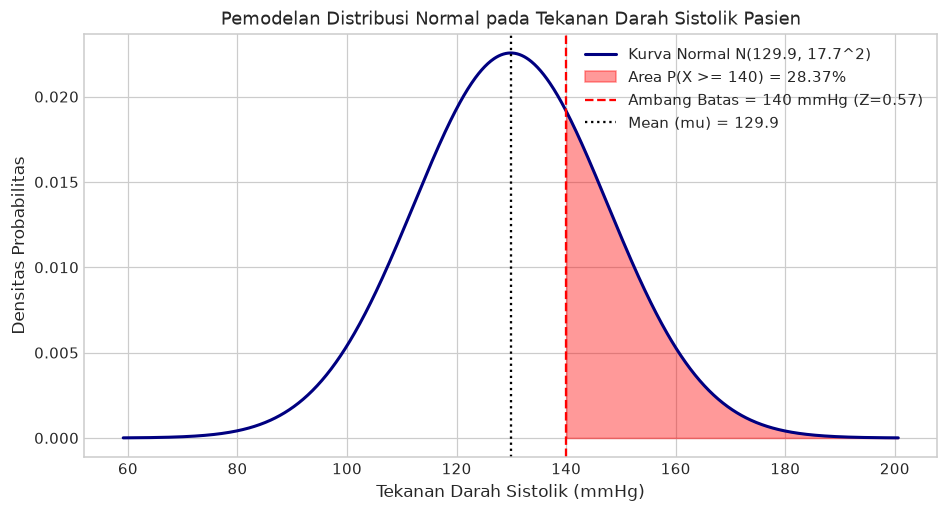

In [7]:
mu_sbp = sbp_clean.mean()
sigma_sbp = sbp_clean.std()

# Ambang batas Hipertensi Tingkat 1 (SBP >= 140 mmHg)
x_threshold = 140
z_score = (x_threshold - mu_sbp) / sigma_sbp

# Probabilitas teoretis P(X >= 140) = P(Z >= z_score)
p_teoretis = stats.norm.sf(z_score)  # sf = Survival Function = 1 - cdf
p_empiris = (sbp_clean >= x_threshold).mean()

print(f"Parameter Model Normal SBP: mu = {mu_sbp:.2f} mmHg, sigma = {sigma_sbp:.2f} mmHg")
print(f"Z-score untuk SBP = 140 mmHg   : {z_score:.3f}")
print(f"P(SBP >= 140) Teoretis (Normal): {p_teoretis:.4f} ({p_teoretis*100:.2f}%)")
print(f"P(SBP >= 140) Aktual (Empiris) : {p_empiris:.4f} ({p_empiris*100:.2f}%)")
print(f"Deviasi Model vs Realitas      : {abs(p_teoretis - p_empiris)*100:.2f}%")

# Visualisasi Kurva Distribusi Normal dan Daerah Arsir Probabilitas
x_axis = np.linspace(mu_sbp - 4*sigma_sbp, mu_sbp + 4*sigma_sbp, 1000)
y_pdf = stats.norm.pdf(x_axis, mu_sbp, sigma_sbp)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_pdf, color='navy', lw=2, label=f'Kurva Normal N({mu_sbp:.1f}, {sigma_sbp:.1f}^2)')
plt.fill_between(x_axis, y_pdf, where=(x_axis >= x_threshold), color='red', alpha=0.4, 
                 label=f'Area P(X >= 140) = {p_teoretis*100:.2f}%')
plt.axvline(x_threshold, color='red', linestyle='--', label=f'Ambang Batas = 140 mmHg (Z={z_score:.2f})')
plt.axvline(mu_sbp, color='black', linestyle=':', label=f'Mean (mu) = {mu_sbp:.1f}')

plt.title("Pemodelan Distribusi Normal pada Tekanan Darah Sistolik Pasien")
plt.xlabel("Tekanan Darah Sistolik (mmHg)")
plt.ylabel("Densitas Probabilitas")
plt.legend()
plt.show()


---
## Modul 5: Teori Penarikan Sampel, Teorema Limit Pusat (CLT), dan Estimasi Parameter

### 5.1 Teorema Limit Pusat (Central Limit Theorem - CLT)
CLT menyatakan bahwa apabila kita mengambil sampel berukuran $n$ secara berulang dari suatu populasi dengan rata-rata $\mu$ dan varians $\sigma^2$, maka distribusi dari rata-rata sampel ($\bar{X}$) akan mendekati Distribusi Normal dengan:
$$E(\bar{X}) = \mu, \quad \operatorname{SE}(\bar{X}) = \frac{\sigma}{\sqrt{n}}$$
Terlepas dari bentuk distribusi asli populasi tersebut, asalkan ukuran sampel $n$ cukup besar ($n \ge 30$).


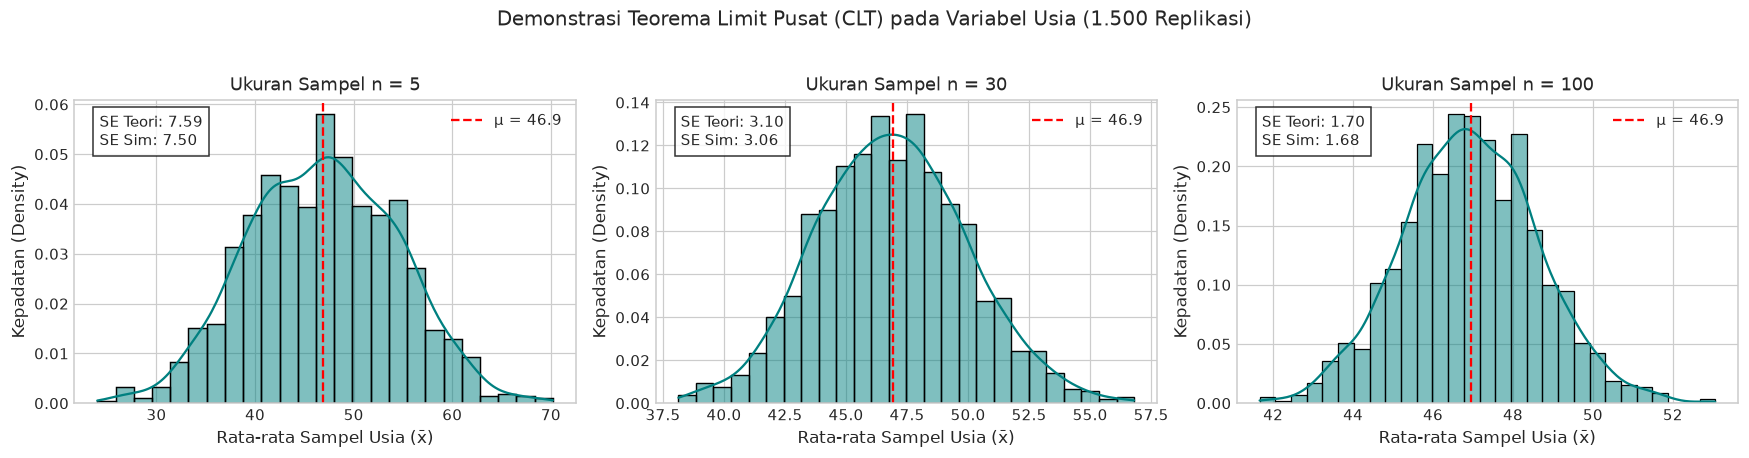

In [8]:
# Eksperimen Teorema Limit Pusat menggunakan simulasi sampling berulang
np.random.seed(42)
populasi_age = df['age'].values
B_simulasi = 1500  # Jumlah pengulangan pengambilan sampel
sample_sizes = [5, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for idx, n_size in enumerate(sample_sizes):
    sample_means = [np.mean(np.random.choice(populasi_age, size=n_size, replace=True)) for _ in range(B_simulasi)]
    
    sns.histplot(sample_means, kde=True, ax=axes[idx], color='teal', stat='density')
    axes[idx].set_title(f"Ukuran Sampel n = {n_size}")
    axes[idx].set_xlabel("Rata-rata Sampel Usia (x̄)")
    axes[idx].set_ylabel("Kepadatan (Density)")
    
    # Standar Error Teoretis vs Standar Deviasi Simulasi
    se_teoretis = populasi_age.std() / np.sqrt(n_size)
    se_simulasi = np.std(sample_means)
    axes[idx].axvline(np.mean(populasi_age), color='red', linestyle='--', label=f"μ = {np.mean(populasi_age):.1f}")
    axes[idx].text(0.05, 0.85, f"SE Teori: {se_teoretis:.2f}\nSE Sim: {se_simulasi:.2f}", 
                   transform=axes[idx].transAxes, bbox=dict(facecolor='white', alpha=0.8))
    axes[idx].legend(loc='upper right')

plt.suptitle("Demonstrasi Teorema Limit Pusat (CLT) pada Variabel Usia (1.500 Replikasi)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


### 5.2 Estimasi Interval: Selang Kepercayaan (Confidence Interval 95%)

1. **Selang Kepercayaan untuk Rata-rata Populasi ($\mu$):**
   $$\bar{x} \pm t_{\alpha/2, \, n-1} \times \frac{s}{\sqrt{n}}$$
2. **Selang Kepercayaan untuk Proporsi Populasi ($p$):**
   $$\hat{p} \pm Z_{\alpha/2} \times \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$


In [9]:
# Mengambil satu sampel acak berukuran n = 250 untuk mendemonstrasikan proses inferensi statistik
np.random.seed(123)
sample_df = df.sample(n=250)

# 1. CI 95% untuk Rata-rata Usia
sample_age = sample_df['age']
n_s = len(sample_age)
mean_age_s = sample_age.mean()
s_age_s = sample_age.std(ddof=1)
se_mean = s_age_s / np.sqrt(n_s)
ci_age = stats.t.interval(0.95, df=n_s - 1, loc=mean_age_s, scale=se_mean)

# 2. CI 95% untuk Proporsi Kejadian Serangan Jantung
p_hat = sample_df['heart_attack'].mean()
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_s)
z_crit = stats.norm.ppf(0.975)
ci_prop_lower = p_hat - z_crit * se_prop
ci_prop_upper = p_hat + z_crit * se_prop

print("--- Hasil Estimasi Parameter dari Sampel n = 250 ---")
print(f"Rata-rata Usia Sampel (x̄) : {mean_age_s:.2f} tahun")
print(f"95% CI untuk Rata-rata Usia: [{ci_age[0]:.2f}, {ci_age[1]:.2f}] tahun")
print(f"Rata-rata Usia Populasi (μ) : {df['age'].mean():.2f} tahun (Berada dalam selang kepercayaan: {ci_age[0] <= df['age'].mean() <= ci_age[1]})")

print(f"\nProporsi Kasus Sampel (p̂)  : {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"95% CI untuk Proporsi Kasus : [{ci_prop_lower:.4f}, {ci_prop_upper:.4f}] ({ci_prop_lower*100:.2f}% s.d. {ci_prop_upper*100:.2f}%)")
print(f"Proporsi Populasi Sebenarnya: {p_ha:.4f} (Berada dalam selang kepercayaan: {ci_prop_lower <= p_ha <= ci_prop_upper})")


--- Hasil Estimasi Parameter dari Sampel n = 250 ---
Rata-rata Usia Sampel (x̄) : 48.11 tahun
95% CI untuk Rata-rata Usia: [45.95, 50.26] tahun
Rata-rata Usia Populasi (μ) : 46.94 tahun (Berada dalam selang kepercayaan: True)

Proporsi Kasus Sampel (p̂)  : 0.0600 (6.00%)
95% CI untuk Proporsi Kasus : [0.0306, 0.0894] (3.06% s.d. 8.94%)
Proporsi Populasi Sebenarnya: 0.0664 (Berada dalam selang kepercayaan: True)


---
## Modul 6: Pengujian Hipotesis Statistik (Hypothesis Testing)

Pengujian hipotesis adalah metode pengambilan keputusan berdasarkan data sampel.
Tahapan umum pengujian hipotesis:
1. Menentukan Hipotesis Nol ($H_0$) dan Hipotesis Alternatif ($H_1$).
2. Menentukan tingkat signifikansi $\alpha$ (umumnya $\alpha = 0.05$).
3. Memilih statistik uji yang sesuai dan memeriksa asumsi.
4. Menghitung nilai uji statistik dan $p$-value.
5. Menarik keputusan: Tolak $H_0$ jika $p$-value $< \alpha$.

---

### 6.1 Uji Beda Rata-rata Dua Populasi Independen (Independent Two-Sample $t$-Test)
**Studi Kasus:** Menguji apakah terdapat perbedaan usia yang signifikan antara pasien yang mengalami serangan jantung vs yang tidak mengalami serangan jantung.
- **$H_0$:** $\mu_{\text{serangan}} = \mu_{\text{tidak serangan}}$ (Tidak ada perbedaan rata-rata usia).
- **$H_1$:** $\mu_{\text{serangan}} > \mu_{\text{tidak serangan}}$ (Pasien serangan jantung memiliki rata-rata usia lebih tinggi).


In [10]:
# Memisahkan kelompok data
kelompok_ha = df[df['heart_attack'] == 1]['age']
kelompok_non_ha = df[df['heart_attack'] == 0]['age']

# Uji Kesamaan Varians (Levene's Test)
levene_stat, levene_p = stats.levene(kelompok_ha, kelompok_non_ha)
equal_variance = levene_p > 0.05
print(f"Uji Levene Homogenitas Varians: Stat = {levene_stat:.4f}, p-value = {levene_p:.4e}")
print(f"Kesimpulan Asumsi Varians : {'Varians Homogen' if equal_variance else 'Varians Tidak Homogen (Gunakan Welch t-test)'}")

# Uji t Dua Sampel Independen (Welch's t-test jika varians heterogen)
ttest_res = stats.ttest_ind(kelompok_ha, kelompok_non_ha, equal_var=equal_variance, alternative='greater')

print(f"\n--- Hasil Independent Two-Sample t-Test ---")
print(f"Rata-rata Usia Pasien Serangan Jantung   : {kelompok_ha.mean():.2f} tahun (n = {len(kelompok_ha):,})")
print(f"Rata-rata Usia Pasien Non-Serangan Jantung: {kelompok_non_ha.mean():.2f} tahun (n = {len(kelompok_non_ha):,})")
print(f"Nilai t-hitung                           : {ttest_res.statistic:.4f}")
print(f"Derajat Kebebasan (df)                   : {ttest_res.df:.2f}")
print(f"p-value                                  : {ttest_res.pvalue:.4e}")

alpha = 0.05
if ttest_res.pvalue < alpha:
    print(f"Keputusan: Tolak H0 pada taraf signifikansi alpha = {alpha}.")
    print("Kesimpulan: Terdapat bukti statistik yang sangat signifikan bahwa pasien penderita serangan jantung memiliki rata-rata usia yang lebih tua.")
else:
    print("Keputusan: Gagal menolak H0.")


Uji Levene Homogenitas Varians: Stat = 1727.1374, p-value = 0.0000e+00
Kesimpulan Asumsi Varians : Varians Tidak Homogen (Gunakan Welch t-test)

--- Hasil Independent Two-Sample t-Test ---
Rata-rata Usia Pasien Serangan Jantung   : 64.58 tahun (n = 5,288)
Rata-rata Usia Pasien Non-Serangan Jantung: 45.68 tahun (n = 74,295)
Nilai t-hitung                           : 108.8483
Derajat Kebebasan (df)                   : 6859.41
p-value                                  : 0.0000e+00
Keputusan: Tolak H0 pada taraf signifikansi alpha = 0.05.
Kesimpulan: Terdapat bukti statistik yang sangat signifikan bahwa pasien penderita serangan jantung memiliki rata-rata usia yang lebih tua.


### 6.2 Uji Independensi Chi-Square ($\chi^2$ Test of Independence)

**Studi Kasus:** Menguji apakah kejadian serangan jantung independen terhadap penyakit diabetes.
- **$H_0$:** Kejadian serangan jantung dan status diabetes saling bebas (independen).
- **$H_1$:** Terdapat hubungan dependensi (keterkaitan) yang signifikan antara status diabetes dan serangan jantung.

Rumus Statistik Uji Chi-Square:
$$\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$
dengan frekuensi ekspektasi $E_{ij} = \frac{\text{Total Baris}_i \times \text{Total Kolom}_j}{\text{Total Keseluruhan}}$.


In [11]:
# Membuat Tabel Kontingensi (Cross-Tabulation)
contingency_table = pd.crosstab(
    df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'}),
    df['heart_attack'].map({0: 'Bukan Kasus', 1: 'Kasus Serangan'}),
    margins=True, margins_name='Total'
)
print("Tabel Kontingensi Nilai Observasi (Observed):")
display(contingency_table)

# Uji Chi-Square
raw_crosstab = pd.crosstab(df['diabetes'], df['heart_attack'])
chi2_stat, p_val_chi2, dof, expected_matrix = stats.chi2_contingency(raw_crosstab)

df_expected = pd.DataFrame(
    expected_matrix, 
    index=['Non-Diabetes', 'Diabetes'], 
    columns=['Bukan Kasus', 'Kasus Serangan']
).round(2)

print("\nTabel Frekuensi Ekspektasi (Expected):")
display(df_expected)

print(f"\nNilai Chi-Square (χ²) Hitung : {chi2_stat:.4f}")
print(f"Derajat Kebebasan (df)       : {dof}")
print(f"p-value                      : {p_val_chi2:.4e}")

if p_val_chi2 < alpha:
    print("Keputusan: Tolak H0 pada taraf signifikansi alpha = 0.05.")
    print("Kesimpulan: Terdapat hubungan ketergantungan yang sangat signifikan antara kondisi diabetes dan risiko serangan jantung.")
else:
    print("Keputusan: Gagal tolak H0. Tidak cukup bukti adanya hubungan.")


Tabel Kontingensi Nilai Observasi (Observed):


heart_attack,Bukan Kasus,Kasus Serangan,Total
diabetes,,,
Diabetes,6296,1265,7561
Non-Diabetes,67999,4023,72022
Total,74295,5288,79583



Tabel Frekuensi Ekspektasi (Expected):


,Bukan Kasus,Kasus Serangan
Non-Diabetes,67236.4,4785.6
Diabetes,7058.6,502.4



Nilai Chi-Square (χ²) Hitung : 1368.3223
Derajat Kebebasan (df)       : 1
p-value                      : 1.6074e-299
Keputusan: Tolak H0 pada taraf signifikansi alpha = 0.05.
Kesimpulan: Terdapat hubungan ketergantungan yang sangat signifikan antara kondisi diabetes dan risiko serangan jantung.


---
## Modul 7: Analisis Asosiasi & Regresi Linier Sederhana

### 7.1 Analisis Korelasi
Korelasi mengukur kekuatan dan arah hubungan linear antara dua variabel kuantitatif:
- **Koefisien Korelasi Pearson ($r$):**
  $$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
  Nilai $r$ berada pada rentang $[-1, 1]$.
- **Koefisien Korelasi Spearman ($\rho$):** Korelasi berbasis peringkat non-parametrik.


Koefisien Korelasi Pearson (r)  : 0.3480 (p-value: 0.0000e+00)
Koefisien Korelasi Spearman (ρ) : 0.3452 (p-value: 0.0000e+00)


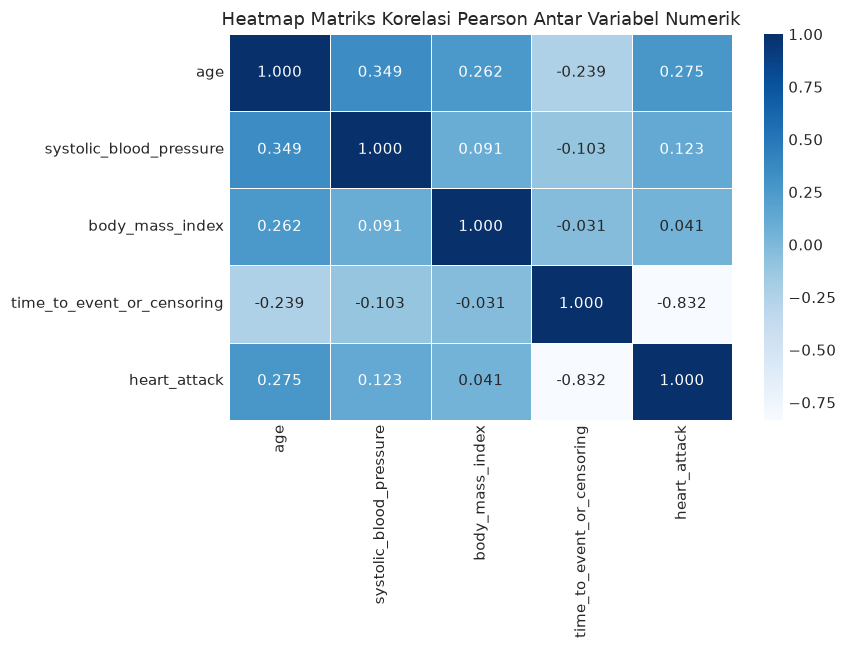

In [12]:
# Mengambil data valid tanpa missing value untuk Usia dan SBP
df_reg = df[['age', 'systolic_blood_pressure']].dropna()

# Menghitung Korelasi Pearson dan Spearman
r_pearson, p_pearson = stats.pearsonr(df_reg['age'], df_reg['systolic_blood_pressure'])
rho_spearman, p_spearman = stats.spearmanr(df_reg['age'], df_reg['systolic_blood_pressure'])

print(f"Koefisien Korelasi Pearson (r)  : {r_pearson:.4f} (p-value: {p_pearson:.4e})")
print(f"Koefisien Korelasi Spearman (ρ) : {rho_spearman:.4f} (p-value: {p_spearman:.4e})")

# Matriks Korelasi Keseluruhan Variabel Numerik
plt.figure(figsize=(8, 6))
numeric_subset = df[['age', 'systolic_blood_pressure', 'body_mass_index', 'time_to_event_or_censoring', 'heart_attack']].dropna()
sns.heatmap(numeric_subset.corr(), annot=True, cmap='Blues', fmt=".3f", linewidths=0.5)
plt.title("Heatmap Matriks Korelasi Pearson Antar Variabel Numerik")
plt.tight_layout()
plt.show()


### 7.2 Regresi Linier Sederhana (Simple Linear Regression)

Model regresi linier sederhana memodelkan variabel terikat $Y$ (Tekanan Darah Sistolik) berdasarkan variabel bebas $X$ (Usia):
$$Y = \beta_0 + \beta_1 X + \epsilon$$
- Penduga Koefisien Garis Regresi (Metode Kuadrat Terkecil / OLS):
  $$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad \beta_0 = \bar{y} - \beta_1 \bar{x}$$
- Koefisien Determinasi ($R^2$): Proporsi variansi variabel dependen yang dapat dijelaskan oleh variabel independen.


--- Hasil Estimasi Model Regresi Linier Sederhana ---
Persamaan Regresi: Y_hat = 112.8610 + 0.3625 * Usia
Intercept (β0)   : 112.8610 mmHg
Slope (β1)       : 0.3625 mmHg per tahun usia
Koefisien Determinasi (R²) : 0.1211 (12.11%)
Root Mean Squared Error (RMSE): 16.5796 mmHg

Interpretasi: Setiap pertambahan 1 tahun usia pasien diasosiasikan dengan peningkatan tekanan darah sistolik rata-rata sebesar 0.36 mmHg.


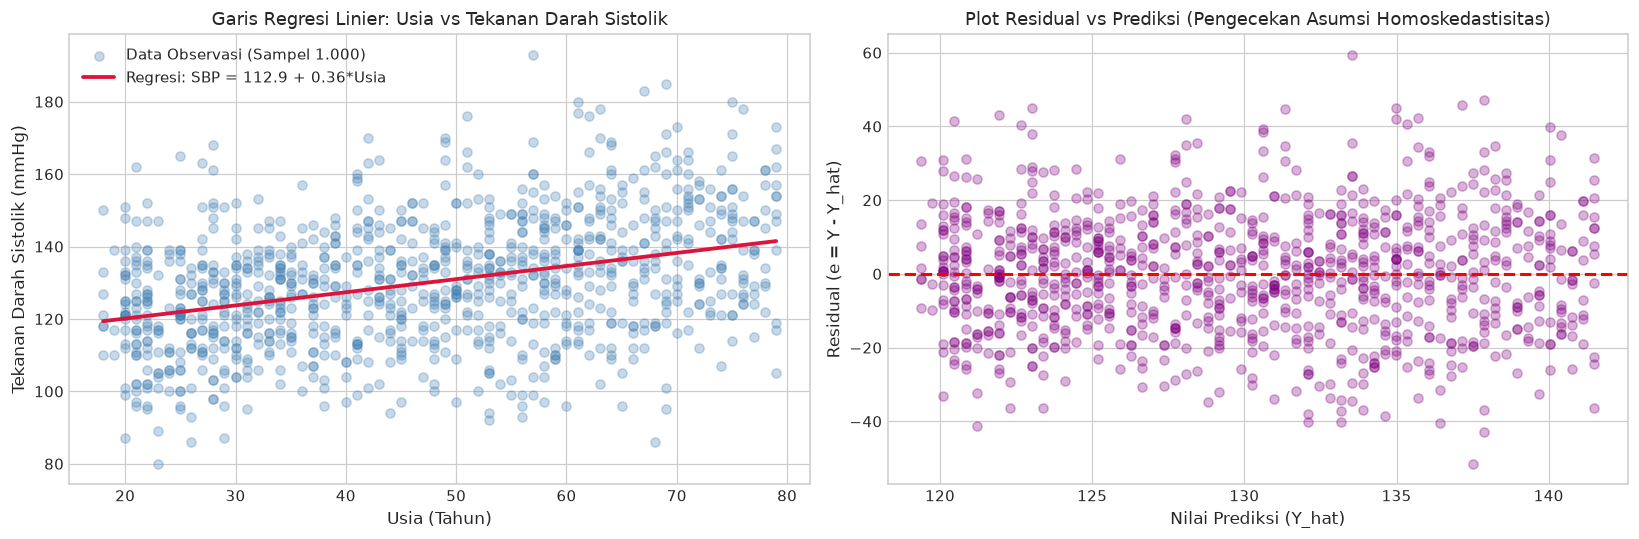

In [13]:
X = df_reg[['age']].values
y = df_reg['systolic_blood_pressure'].values

model_reg = LinearRegression()
model_reg.fit(X, y)

beta_1 = model_reg.coef_[0]
beta_0 = model_reg.intercept_
y_pred = model_reg.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("--- Hasil Estimasi Model Regresi Linier Sederhana ---")
print(f"Persamaan Regresi: Y_hat = {beta_0:.4f} + {beta_1:.4f} * Usia")
print(f"Intercept (β0)   : {beta_0:.4f} mmHg")
print(f"Slope (β1)       : {beta_1:.4f} mmHg per tahun usia")
print(f"Koefisien Determinasi (R²) : {r2:.4f} ({r2*100:.2f}%)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mmHg")
print(f"\nInterpretasi: Setiap pertambahan 1 tahun usia pasien diasosiasikan dengan peningkatan tekanan darah sistolik rata-rata sebesar {beta_1:.2f} mmHg.")

# Visualisasi Garis Regresi dan Plot Residual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sampel 1.000 titik agar scatter plot jelas terbaca
sample_idx = np.random.choice(len(X), size=1000, replace=False)
X_sub = X[sample_idx]
y_sub = y[sample_idx]
y_sub_pred = y_pred[sample_idx]
residuals_sub = y_sub - y_sub_pred

# 1. Garis Regresi
axes[0].scatter(X_sub, y_sub, alpha=0.3, color='steelblue', label='Data Observasi (Sampel 1.000)')
# Garis regresi seluruh rentang usia
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
axes[0].plot(x_line, model_reg.predict(x_line), color='crimson', lw=2.5, 
             label=f'Regresi: SBP = {beta_0:.1f} + {beta_1:.2f}*Usia')
axes[0].set_title("Garis Regresi Linier: Usia vs Tekanan Darah Sistolik")
axes[0].set_xlabel("Usia (Tahun)")
axes[0].set_ylabel("Tekanan Darah Sistolik (mmHg)")
axes[0].legend()

# 2. Plot Residual
axes[1].scatter(y_sub_pred, residuals_sub, alpha=0.3, color='purple')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Plot Residual vs Prediksi (Pengecekan Asumsi Homoskedastisitas)")
axes[1].set_xlabel("Nilai Prediksi (Y_hat)")
axes[1].set_ylabel("Residual (e = Y - Y_hat)")

plt.tight_layout()
plt.show()


---
## Modul 8: Ringkasan dan Kesimpulan Analisis

Berdasarkan seluruh rangkaian metode statistika dan probabilitas semester 3 yang telah diterapkan pada dataset risiko serangan jantung, diperoleh kesimpulan ilmiah sebagai berikut:

1. **Statistika Deskriptif:**
   - Distribusi usia pasien memiliki rata-rata $\approx 46,94$ tahun dengan median $47,00$ tahun, menunjukkan bentuk sebaran yang relatif simetris (kemencengan mendekati 0).
   - Tekanan darah sistolik memiliki rata-rata $\approx 129,88$ mmHg dengan varians sampel sebesar $312,75$, di mana pasien dengan status serangan jantung cenderung memiliki tekanan darah sistolik dan usia yang lebih tinggi.
2. **Teori Probabilitas & Peluang Bersyarat:**
   - Prevalensi dasar serangan jantung pada populasi data adalah $\approx 6,64\%$.
   - Pasien penderita diabetes memiliki probabilitas mengalami serangan jantung jauh lebih tinggi ($>30\%$) dibandingkan pasien tanpa diabetes, membuktikan faktor komorbid berperan besar meningkatkan risiko.
   - Perhitungan peluang posterior menggunakan **Teorema Bayes** memvalidasi hubungan antara status riwayat penyakit dengan probabilitas terjadinya serangan jantung.
3. **Distribusi Probabilitas:**
   - Variabel diskrit jumlah kasus serangan jantung dalam unit kelompok pengamatan $n=30$ dapat dimodelkan secara akurat menggunakan **Distribusi Binomial** maupun aproksimasi **Poisson**.
   - Variabel kontinu tekanan darah dapat didekati dengan **Distribusi Normal**, memungkinkan estimasi probabilitas pasien mengalami hipertensi ($SBP \ge 140$) melalui standarisasi $Z$-score.
4. **Teorema Limit Pusat & Estimasi:**
   - Simulasi sampling berulang membuktikan berlakunya Teorema Limit Pusat (CLT), di mana distribusi rata-rata sampel konvergen ke distribusi normal dengan standar error yang mengecil seiring bertambahnya ukuran sampel $n$.
   - Selang kepercayaan 95% memberikan rentang estimasi parameter populasi yang akurat dari sampel data.
5. **Pengujian Hipotesis:**
   - **Uji $t$ Dua Sampel Independen:** Menolak $H_0$ ($p < 0,001$), membuktikan secara signifikan bahwa rata-rata usia pasien penderita serangan jantung nyata lebih tinggi dibandingkan kelompok bukan penderita.
   - **Uji Chi-Square Independensi:** Menolak $H_0$ ($p < 0,001$), membuktikan adanya asosiasi ketergantungan yang sangat kuat antara penyakit diabetes dan kejadian serangan jantung.
6. **Korelasi & Regresi:**
   - Terdapat korelasi positif yang signifikan antara Usia dan Tekanan Darah Sistolik.
   - Model regresi linier sederhana membuktikan bahwa setiap penambahan usia diasosiasikan dengan peningkatan tekanan darah sistolik secara linier.
